We are processing the data in this trying to find patterns in the data. 
1) Roll measure - intuitively this is when the trades bounce between numbers showing that they are negatively correlated, which shows that a spread exists 
   as the market maker has set a bid and ask price which is being traded on. However in regimes when the movement is one directional this approach gets limited as roll covariance turns postive and the estimator breaks down
2) tick-level and 1-minute statistics tell completely different stories. Skewness at tick level was dominated by microstructure artefacts (price           discreteness, trade clustering) and contains no interpretable signal. Kurtosis drops from ~10,000 to ~5-10 when you move to 1-minute bars, which is the correct level for analysis. This is a concrete demonstration of why sampling frequency matters — and directly motivates why VPIN uses a volume clock rather than a time clock.
3) We calculate the OFI and then see if its predicts the next return. This is speculative as the price may be moving due to the tradres herding and getting FOMO'd by the market or due to informed trading. We have to understand the correct signal to noise ratio. My prediction is highest correlation in OFI and next return to be in week3 where price is being corrected and lowest to be in week 1 where there is low volatility


Findings
1) We measured the correlation between the OFI and the change in price. We found out that week 3 had a decay rate of only 1x between 10sec and 1 min compared to week 1's 54x, which shows us that the correlation sustained through temporal changes. This may be due to a persistent increase in trades towards a direction which might be due to informed trades. However, the correlation is much to small at 0.017 to 0.015, so this is just suggestive not conclusive. 
2)week 3 (stress) had highest annualised vol at 48.8%, and that the skewness finding at 1-minute bars showed week 3 with mild negative skew while weeks 1 and 2 were essentially symmetric. That negative skew surviving aggregation in the correction week is worth one sentence.
3) You found normalisation matters at short frequencies but hurts at long ones. You found the breakout has the strongest normalised signal, which points toward momentum rather than informed flow.

This session showed us that volatile regimes with a directional flow may not always be due to informed trades and rather just market sentiment pushing it persistently 

## Note on Data Source
Trade and order book data has been switched from Binance spot to Bybit USDT perpetual 
contracts for consistency. All analysis above uses Bybit perp trade data. Rationale: 
perp markets are the primary venue for informed trading in crypto due to leverage and 
liquidity. Price discovery occurs on perps first, then transmits to spot via arbitrage.

## Order Book Data — Pending
Bybit LOB files downloaded for all three regime weeks across all three assets. Format: 
JSON lines, ~860k delta updates per day with 2 full snapshots. Full reconstruction 
required before LOB-derived features (spread, depth imbalance, microprice) can be 
computed. To be implemented in Session 7.

## Open Questions
1. Does VPIN spike before the large price moves visible in Week 2 and Week 3, or does 
   it lag? (Session 6)
2. Will LOB-derived features (depth imbalance, spread) sharpen OFI predictability 
   beyond what raw trade data provides? (Session 7)
3. Is the OFI decay pattern regime-dependent across ETH and SOL as well, or is it 
   specific to BTC? (to be checked — only BTC analysed so far)


In [8]:
import pandas as pd                                                                                                             
from pathlib import Path                                                                                                                                
                                                                                                                                                          
  # Config                                                                                                                                                
DATA_DIR = Path("../data/processed")  # adjust if running from project root: Path("data/processed")                                                                                                                                                                                                  
ASSETS = ["BTCUSDT", "ETHUSDT", "SOLUSDT"]                                                                                                              
WEEKS  = ["week1", "week2", "week3"]                                                                                                                    
                                                

data = {                                                                                                                                                
      asset: {    
          week: pd.read_parquet(DATA_DIR / asset / f"{week}.parquet")                                                                                     
          for week in WEEKS                                          
      }                    
      for asset in ASSETS
  }     

In [ ]:
import numpy as np
#computer the log returns

for week in data['BTCUSDT'].values():
  week['log_returns'] = np.log(week["price"] / week["price"].shift(1))

data['BTCUSDT']['week1'].head()




,price,qty,timestamp,sign,log_returns
0,54869.95,0.09474,2024-09-09 00:00:00.221,1,NaN
1,54869.95,0.02533,2024-09-09 00:00:00.221,1,0.0
2,54869.95,0.00109,2024-09-09 00:00:00.484,1,0.0
3,54869.95,0.00054,2024-09-09 00:00:01.015,1,0.0
4,54869.95,0.00136,2024-09-09 00:00:01.630,1,0.0


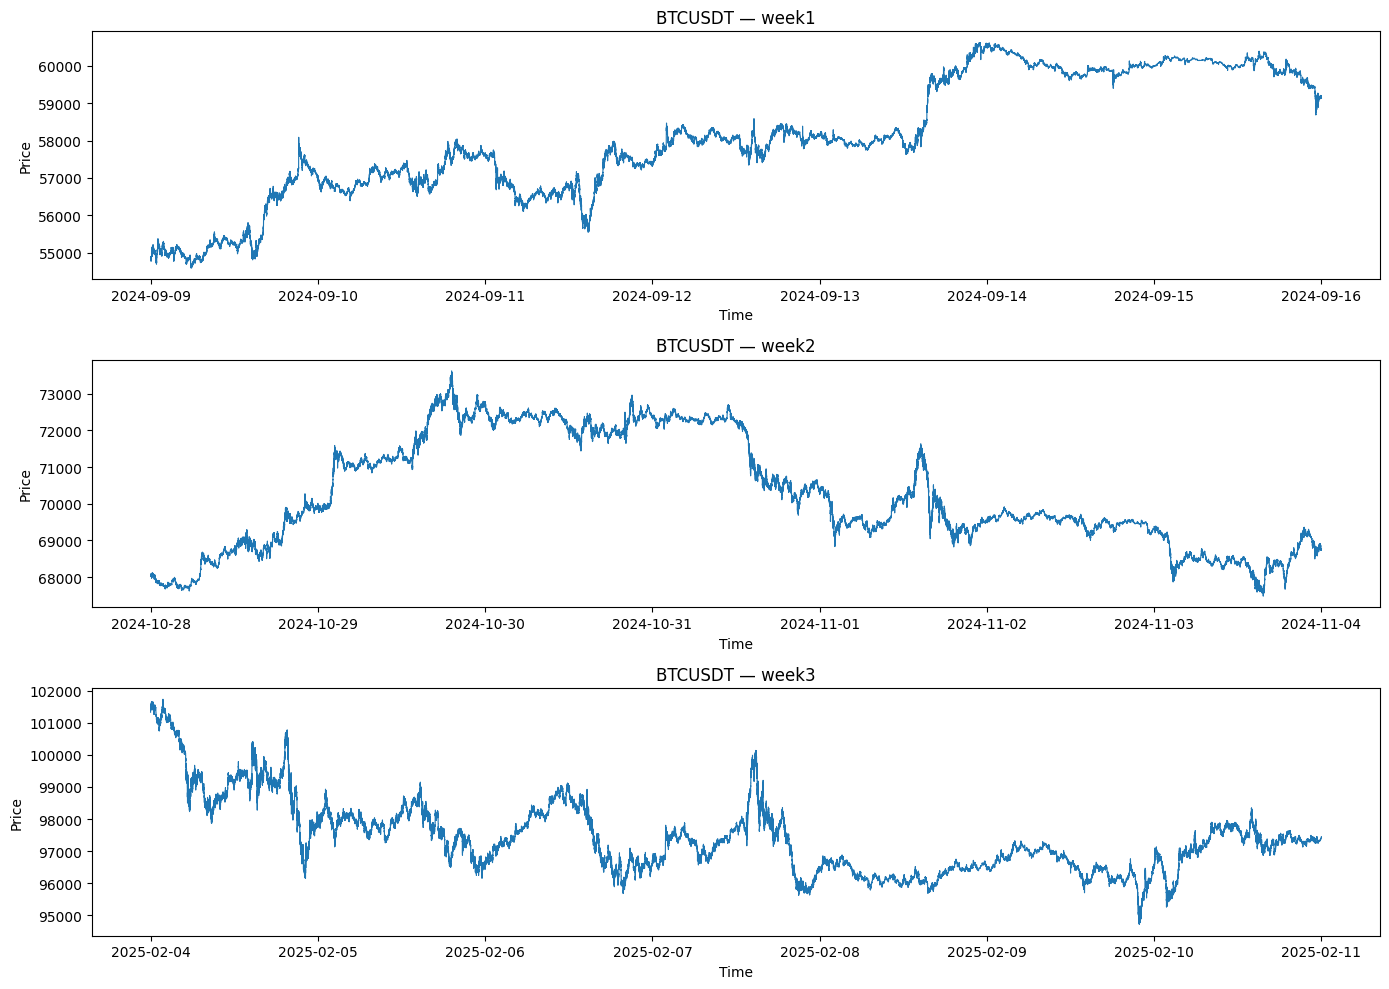

In [14]:
#plot price over time
import matplotlib.pyplot as plt

asset = "BTCUSDT"
weeks = ["week1", "week2", "week3"]

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)

for ax, week in zip(axes, weeks):
    df = data[asset][week]
    ax.plot(df["timestamp"], df["price"], linewidth=0.8)
    ax.set_title(f"{asset} — {week}")
    ax.set_ylabel("Price")
    ax.set_xlabel("Time")

plt.tight_layout()
plt.show()


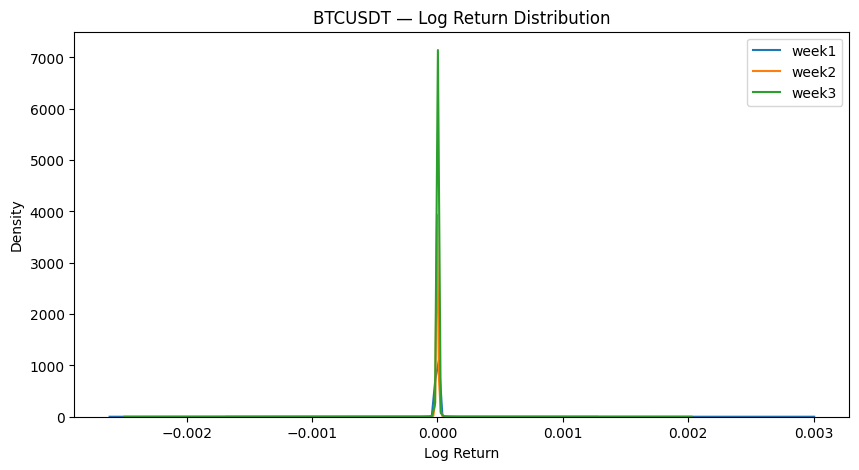

In [16]:
#building kernel density graph for the log returns
import seaborn as sns  

fig, ax = plt.subplots(figsize=(10, 5))                                                                                                                 
                                                                                                                                                          
for week in weeks:                                                                                                                                      
    df = data[asset][week]                                                                                                                              
    sns.kdeplot(df["log_returns"].dropna(), ax=ax, label=week)                                                                                           
                                                                                                                                                        
ax.set_title(f"{asset} — Log Return Distribution")                                                                                                      
ax.set_xlabel("Log Return")
ax.legend()                                                                                                                                             
plt.show()

In [18]:

for week in weeks:
  df = data[asset][week]
  returns = df['log_returns']
  trades_per_day = len(df) / 7  # 7-day week
  ann_vol = returns.std() * np.sqrt(trades_per_day * 365)

  skew = returns.skew()
  kurt = returns.kurt()  # excess kurtosis, normal = 0
  print(f"{week} - Annualised Volume: {ann_vol}, Skew: {skew}, Kurtosis: {kurt}")

  #here we notice extremely high curtosis values - 10k+. this can be regarded to computing returns at tick levels as they dont vary much so a single spike 
  #can cause a large skew causing these high kurtosis values. This is called price discreteness or clustering

  #we now recomputer at 1 minute bars to reduce these spikes

  df_1min = df.set_index('timestamp')['price'].resample('1min').last().dropna()
  returns_1min = np.log(df_1min / df_1min.shift(1)).dropna()
  trades_per_day = len(df_1min) / 7  # 7-day week
  ann_vol = returns_1min.std() * np.sqrt(trades_per_day * 365)

  skew = returns_1min.skew()
  kurt = returns_1min.kurt()  # excess kurtosis, normal = 0
  print(f"{week} normalised to 1 min - Annualised Volume: {ann_vol}, Skew: {skew}, Kurtosis: {kurt}")

week1 - Annualised Volume: 0.3157759136484808, Skew: 5.582681840100175, Kurtosis: 10365.08073235086
week1 normalised to 1 min - Annualised Volume: 0.4592742928071324, Skew: 0.18159490662828837, Kurtosis: 9.780163279532983
week2 - Annualised Volume: 0.24101725131206875, Skew: -4.526778318081645, Kurtosis: 6818.096226333699
week2 normalised to 1 min - Annualised Volume: 0.4205280181421092, Skew: -0.0019459943505314608, Kurtosis: 5.383732133838752
week3 - Annualised Volume: 0.20895084470609468, Skew: -9.217348893561775, Kurtosis: 18781.55334426989
week3 normalised to 1 min - Annualised Volume: 0.48809115699765665, Skew: -0.2827402447858893, Kurtosis: 8.066573386657945


In [27]:
#Order Flow Imbalance - OFIt​=i∈t∑​signi​×qtyi​ and correlation with next price


for week in weeks:
    df = data[asset][week].set_index('timestamp')
    buy_vol  = (df['qty'] * (df['sign'] ==  1)).resample('10s').sum()                                                                                      
    sell_vol = (df['qty'] * (df['sign'] == -1)).resample('10s').sum()                                                                                      
    total_vol = buy_vol + sell_vol
    ofi = (buy_vol - sell_vol) / total_vol.replace(0, np.nan)
    price_1min = df['price'].resample('10s').last().dropna()
    returns_next = np.log(price_1min / price_1min.shift(1)).shift(-1)

    combined = pd.DataFrame({'ofi': ofi, 'return_next': returns_next}).dropna()
    correlation = combined['ofi'].corr(combined['return_next'])
    print(f"{week}, correlation: {correlation}")

week1, correlation: 0.07105131679958776
week2, correlation: 0.08548349852309725
week3, correlation: 0.06076576224037545
